# Notebook 1.4 — Interconnector Flows

This notebook examines how two key NEM interconnectors smooth prices when transfers are available and how connected regions separate when flows become operationally tight. It stays deliberately in the realised-outcomes lane: **flows, regional prices, and regional net interchange only**.

The analysis uses the full locally cached span from **2025-01-01 to 2026-02-28** and focuses on:
- `V-SA` as the headline VIC-SA interconnector series
- `T-V-MNSP1` as the TAS-VIC interconnector series

Important limitation:
- the local `nemosis` parquet cache preserves realised flow fields such as `MWFLOW`, but it does **not** preserve raw `EXPORTLIMIT` / `IMPORTLIMIT`
- throughout this notebook, **utilisation** means `abs(MWFLOW)` divided by the **largest observed absolute flow in the sample**, not true transfer-limit utilisation

A short note on scope: the cache also contains `V-S-MNSP1`, but this notebook intentionally leaves that series aside to keep Notebook 1.4 aligned with the simpler learning goal. Exact binding attribution belongs in Notebook 1.5.

In [7]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

CACHE_DIR = Path('data/nemosis_cache')
TS_FORMAT = '%Y/%m/%d %H:%M:%S'
TARGET_INTERCONNECTORS = {
    'V-SA': ('VIC1', 'SA1'),
    'T-V-MNSP1': ('TAS1', 'VIC1'),
}
START_DATE = pd.Timestamp('2025-01-01')
END_DATE = pd.Timestamp('2026-02-28 23:55:00')
VSA_SPOTLIGHT_START = pd.Timestamp('2026-01-25 00:00:00')
VSA_SPOTLIGHT_END = pd.Timestamp('2026-01-27 00:00:00')

COLOR_MAP = {
    'V-SA': '#0f766e',
    'T-V-MNSP1': '#1d4ed8',
}
SPREAD_COLOR = '#b45309'

In [8]:
def cache_files(table_name: str) -> list[str]:
    files = sorted(CACHE_DIR.glob(f'PUBLIC_*#{table_name}#FILE01#*.parquet'))
    if not files:
        raise FileNotFoundError(f'No parquet files found for {table_name} under {CACHE_DIR}')
    return [str(path) for path in files]


def scan_selected(table_name: str, columns: list[str]) -> pl.LazyFrame:
    # Read selected columns file-by-file so cache-wide schema drift in unused columns
    # does not break the scan.
    return pl.concat(
        [pl.scan_parquet(path).select(columns) for path in cache_files(table_name)],
        how='diagonal_relaxed',
    )


def with_interval_end(lf: pl.LazyFrame) -> pl.LazyFrame:
    return lf.with_columns(
        pl.col('SETTLEMENTDATE').str.strptime(pl.Datetime, format=TS_FORMAT).alias('interval_end')
    )


def duration_curve(series: pd.Series, descending: bool = True) -> pd.DataFrame:
    ordered = series.sort_values(ascending=not descending).reset_index(drop=True)
    pct = np.linspace(0, 100, len(ordered), endpoint=False)
    return pd.DataFrame({'percent_of_intervals': pct, 'value': ordered})


def add_median_by_bin(ax, x: pd.Series, y: pd.Series, bins: np.ndarray, color: str) -> None:
    centers = []
    medians = []
    for left, right in zip(bins[:-1], bins[1:]):
        if right == bins[-1]:
            mask = (x >= left) & (x <= right)
        else:
            mask = (x >= left) & (x < right)
        if mask.any():
            centers.append((left + right) / 2)
            medians.append(float(np.nanmedian(y[mask])))
    ax.plot(centers, medians, color=color, linewidth=2.5, marker='o', markersize=4)

## Load And Validate The Analysis Data

The notebook scans only the columns it actually needs, filters to `INTERVENTION = 0`, and then builds one normalized analysis frame per target interconnector.

In [9]:
flow = (
    with_interval_end(
        scan_selected(
            'DISPATCHINTERCONNECTORRES',
            ['SETTLEMENTDATE', 'INTERCONNECTORID', 'INTERVENTION', 'MWFLOW', 'METEREDMWFLOW'],
        )
    )
    .filter(pl.col('INTERVENTION') == 0)
    .filter(pl.col('INTERCONNECTORID').is_in(list(TARGET_INTERCONNECTORS)))
    .filter(pl.col('interval_end').is_between(START_DATE, END_DATE, closed='both'))
    .select(
        'interval_end',
        pl.col('INTERCONNECTORID').alias('interconnector_id'),
        pl.col('MWFLOW').alias('mw_flow'),
        pl.col('METEREDMWFLOW').alias('metered_mw_flow'),
    )
)

price = (
    with_interval_end(
        scan_selected('DISPATCHPRICE', ['SETTLEMENTDATE', 'REGIONID', 'INTERVENTION', 'RRP'])
    )
    .filter(pl.col('INTERVENTION') == 0)
    .filter(pl.col('REGIONID').is_in(['VIC1', 'SA1', 'TAS1']))
    .filter(pl.col('interval_end').is_between(START_DATE, END_DATE, closed='both'))
    .select('interval_end', 'REGIONID', 'RRP')
)

regionsum = (
    with_interval_end(
        scan_selected(
            'DISPATCHREGIONSUM',
            ['SETTLEMENTDATE', 'REGIONID', 'INTERVENTION', 'NETINTERCHANGE'],
        )
    )
    .filter(pl.col('INTERVENTION') == 0)
    .filter(pl.col('REGIONID').is_in(['VIC1', 'SA1', 'TAS1']))
    .filter(pl.col('interval_end').is_between(START_DATE, END_DATE, closed='both'))
    .select('interval_end', 'REGIONID', 'NETINTERCHANGE')
)

frames = []
for interconnector_id, (region_a, region_b) in TARGET_INTERCONNECTORS.items():
    frame = (
        flow.filter(pl.col('interconnector_id') == interconnector_id)
        .join(
            price.filter(pl.col('REGIONID') == region_a).select(
                'interval_end', pl.col('RRP').alias('rrp_a')
            ),
            on='interval_end',
            how='inner',
        )
        .join(
            price.filter(pl.col('REGIONID') == region_b).select(
                'interval_end', pl.col('RRP').alias('rrp_b')
            ),
            on='interval_end',
            how='inner',
        )
        .join(
            regionsum.filter(pl.col('REGIONID') == region_a).select(
                'interval_end', pl.col('NETINTERCHANGE').alias('net_interchange_a')
            ),
            on='interval_end',
            how='inner',
        )
        .join(
            regionsum.filter(pl.col('REGIONID') == region_b).select(
                'interval_end', pl.col('NETINTERCHANGE').alias('net_interchange_b')
            ),
            on='interval_end',
            how='inner',
        )
        .with_columns(
            pl.lit(region_a).alias('region_a'),
            pl.lit(region_b).alias('region_b'),
        )
    )
    frames.append(frame)

analysis = (
    pl.concat(frames)
    .with_columns(
        pl.col('mw_flow').abs().alias('abs_flow'),
        (pl.col('rrp_a') - pl.col('rrp_b')).alias('price_spread'),
    )
    .with_columns(
        pl.col('price_spread').abs().alias('abs_price_spread'),
        pl.col('abs_flow').max().over('interconnector_id').alias('observed_abs_max_mw'),
    )
    .with_columns(
        (pl.col('abs_flow') / pl.col('observed_abs_max_mw')).alias('utilisation_proxy')
    )
    .sort(['interconnector_id', 'interval_end'])
    .collect()
)

assert analysis['interval_end'].null_count() == 0, 'Parsed timestamps should not contain nulls.'
duplicate_check = analysis.group_by(['interconnector_id', 'interval_end']).len().filter(pl.col('len') != 1)
assert duplicate_check.is_empty(), 'Each interconnector should have one joined row per interval.'
assert set(analysis['interconnector_id'].unique().to_list()) == set(TARGET_INTERCONNECTORS), 'Both target interconnectors should be present.'

print(f'Analysis rows: {analysis.height:,}')
print(f"Date span: {analysis['interval_end'].min()} to {analysis['interval_end'].max()}")
print('Note: METEREDMWFLOW is loaded for reference only; the notebook uses MWFLOW as the canonical realised flow series.')
analysis.head()

Analysis rows: 244,224
Date span: 2025-01-01 00:00:00 to 2026-02-28 23:55:00
Note: METEREDMWFLOW is loaded for reference only; the notebook uses MWFLOW as the canonical realised flow series.


interval_end,interconnector_id,mw_flow,metered_mw_flow,rrp_a,rrp_b,net_interchange_a,net_interchange_b,region_a,region_b,abs_flow,price_spread,abs_price_spread,observed_abs_max_mw,utilisation_proxy
datetime[μs],str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64
2025-01-01 00:00:00,"""T-V-MNSP1""",-143.0,-96.4,120.28,118.74373,-143.0,803.09,"""TAS1""","""VIC1""",143.0,1.53627,1.53627,594.0,0.240741
2025-01-01 00:05:00,"""T-V-MNSP1""",-90.7119,-151.40001,125.17761,130.0,-90.71,650.55,"""TAS1""","""VIC1""",90.7119,-4.82239,4.82239,594.0,0.152714
2025-01-01 00:10:00,"""T-V-MNSP1""",-100.0,-89.1,120.28,125.5,-100.0,705.36,"""TAS1""","""VIC1""",100.0,-5.22,5.22,594.0,0.16835
2025-01-01 00:15:00,"""T-V-MNSP1""",-108.39438,-114.1,129.97176,129.0234,-108.39,678.52,"""TAS1""","""VIC1""",108.39438,0.94836,0.94836,594.0,0.182482
2025-01-01 00:20:00,"""T-V-MNSP1""",-136.97324,-114.7,118.28,116.96976,-136.97,623.41,"""TAS1""","""VIC1""",136.97324,1.31024,1.31024,594.0,0.230595


## Section 1 — Flow Overview

Start with a compact diagnostic summary, then inspect two spotlight slices:
- `V-SA`: the same 48-hour SA event window used in Notebook 1.3
- `T-V-MNSP1`: the day with the largest absolute TAS-VIC price spread in the sample

In [10]:
summary = (
    analysis.group_by('interconnector_id')
    .agg(
        pl.min('mw_flow').alias('min_flow_mw'),
        pl.max('mw_flow').alias('max_flow_mw'),
        pl.median('abs_flow').alias('median_abs_flow_mw'),
        pl.max('observed_abs_max_mw').alias('observed_abs_max_mw'),
        (pl.col('mw_flow') < 0).mean().alias('share_reverse_flow'),
        (pl.col('utilisation_proxy') >= 0.8).mean().alias('share_ge_80_proxy_utilisation'),
        (pl.col('mw_flow') - pl.col('metered_mw_flow')).abs().mean().alias('mean_abs_flow_meter_gap_mw'),
    )
    .sort('interconnector_id')
    .with_columns(
        (100 * pl.col('share_reverse_flow')).alias('share_reverse_flow_pct'),
        (100 * pl.col('share_ge_80_proxy_utilisation')).alias('share_ge_80_proxy_utilisation_pct'),
    )
    .select(
        'interconnector_id',
        'min_flow_mw',
        'max_flow_mw',
        'median_abs_flow_mw',
        'observed_abs_max_mw',
        'share_reverse_flow_pct',
        'share_ge_80_proxy_utilisation_pct',
        'mean_abs_flow_meter_gap_mw',
    )
)

display(summary.to_pandas().round(2))

,interconnector_id,min_flow_mw,max_flow_mw,median_abs_flow_mw,observed_abs_max_mw,share_reverse_flow_pct,share_ge_80_proxy_utilisation_pct,mean_abs_flow_meter_gap_mw
0,T-V-MNSP1,-478.0,594.00,182.46,594.00,60.00,7.22,21.50
1,V-SA,-700.0,718.72,241.36,718.72,41.72,6.66,46.45


In [11]:
spotlight_tas_day = (
    analysis.filter(pl.col('interconnector_id') == 'T-V-MNSP1')
    .with_columns(pl.col('interval_end').dt.date().alias('date'))
    .group_by('date')
    .agg(pl.max('abs_price_spread').alias('max_abs_price_spread'))
    .sort('max_abs_price_spread', descending=True)
    .row(0, named=True)
)

TAS_SPOTLIGHT_START = pd.Timestamp(spotlight_tas_day['date'])
TAS_SPOTLIGHT_END = TAS_SPOTLIGHT_START + pd.Timedelta(days=1)

spotlight_windows = {
    'V-SA': (VSA_SPOTLIGHT_START, VSA_SPOTLIGHT_END),
    'T-V-MNSP1': (TAS_SPOTLIGHT_START, TAS_SPOTLIGHT_END),
}

spotlight_tas_day

{'date': datetime.date(2026, 1, 12), 'max_abs_price_spread': 20305.73}

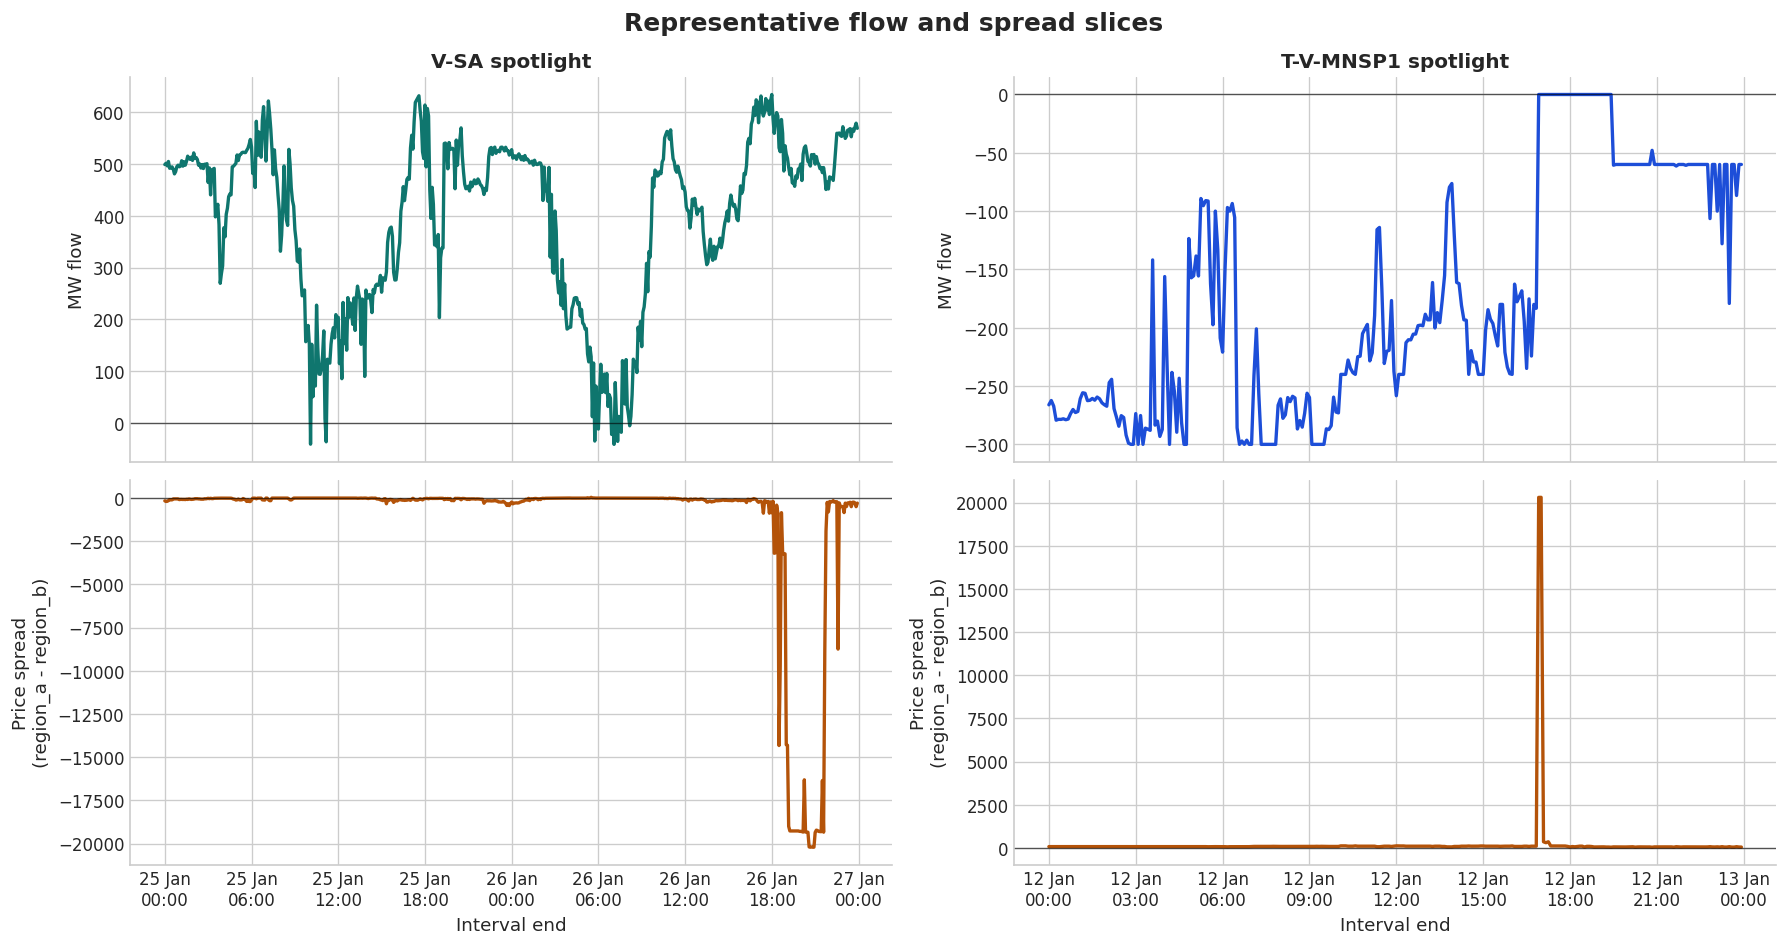

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex='col')

for col, interconnector_id in enumerate(['V-SA', 'T-V-MNSP1']):
    start, end = spotlight_windows[interconnector_id]
    df = (
        analysis.filter(
            (pl.col('interconnector_id') == interconnector_id)
            & pl.col('interval_end').is_between(start, end, closed='left')
        )
        .to_pandas()
        .sort_values('interval_end')
    )

    ax_flow = axes[0, col]
    ax_spread = axes[1, col]
    ax_flow.plot(df['interval_end'], df['mw_flow'], color=COLOR_MAP[interconnector_id], linewidth=2)
    ax_flow.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax_flow.set_title(f'{interconnector_id} spotlight')
    ax_flow.set_ylabel('MW flow')

    ax_spread.plot(df['interval_end'], df['price_spread'], color=SPREAD_COLOR, linewidth=2)
    ax_spread.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax_spread.set_ylabel('Price spread\n(region_a - region_b)')
    ax_spread.set_xlabel('Interval end')

    for ax in (ax_flow, ax_spread):
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))

fig.suptitle('Representative flow and spread slices', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## Section 2 — Flow Duration Curves

Two views matter here:
- a **signed** duration curve, which shows dominant direction and how often the interconnector reverses
- an **absolute-flow proxy** duration curve, which shows how often it operates near the largest flow actually observed in the sample

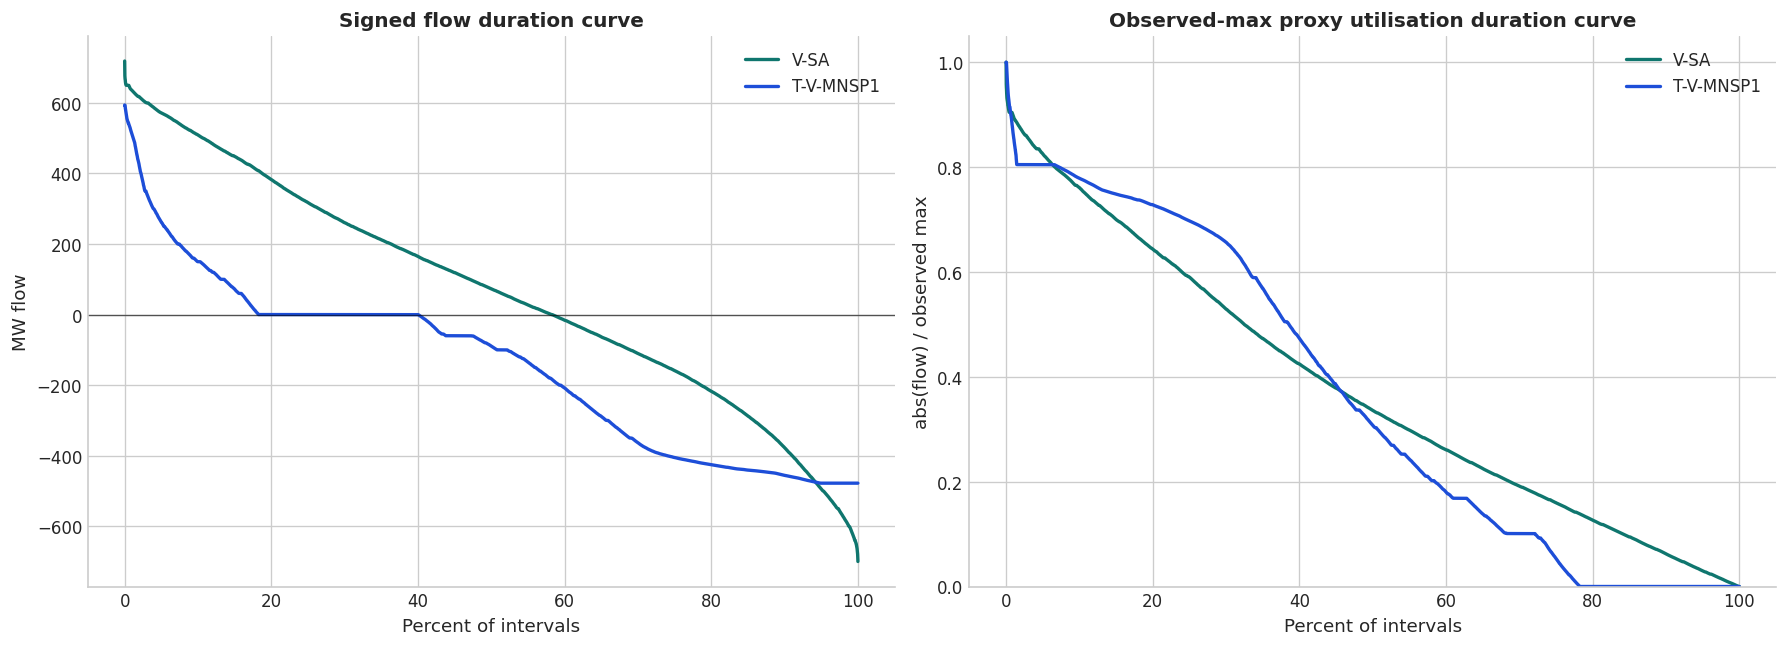

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for interconnector_id in ['V-SA', 'T-V-MNSP1']:
    df = analysis.filter(pl.col('interconnector_id') == interconnector_id).to_pandas()

    signed_curve = duration_curve(df['mw_flow'], descending=True)
    util_curve = duration_curve(df['utilisation_proxy'], descending=True)

    axes[0].plot(
        signed_curve['percent_of_intervals'],
        signed_curve['value'],
        label=interconnector_id,
        linewidth=2,
        color=COLOR_MAP[interconnector_id],
    )
    axes[1].plot(
        util_curve['percent_of_intervals'],
        util_curve['value'],
        label=interconnector_id,
        linewidth=2,
        color=COLOR_MAP[interconnector_id],
    )

axes[0].axhline(0, color='black', linewidth=0.8, alpha=0.6)
axes[0].set_title('Signed flow duration curve')
axes[0].set_xlabel('Percent of intervals')
axes[0].set_ylabel('MW flow')
axes[0].legend()

axes[1].set_title('Observed-max proxy utilisation duration curve')
axes[1].set_xlabel('Percent of intervals')
axes[1].set_ylabel('abs(flow) / observed max')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

fig.tight_layout()
plt.show()

## Section 3 — Price Separation Vs Flow Tightness

The first row relates absolute price separation to the observed-max utilisation proxy. The second row keeps the sign on both axes to show directional asymmetry.

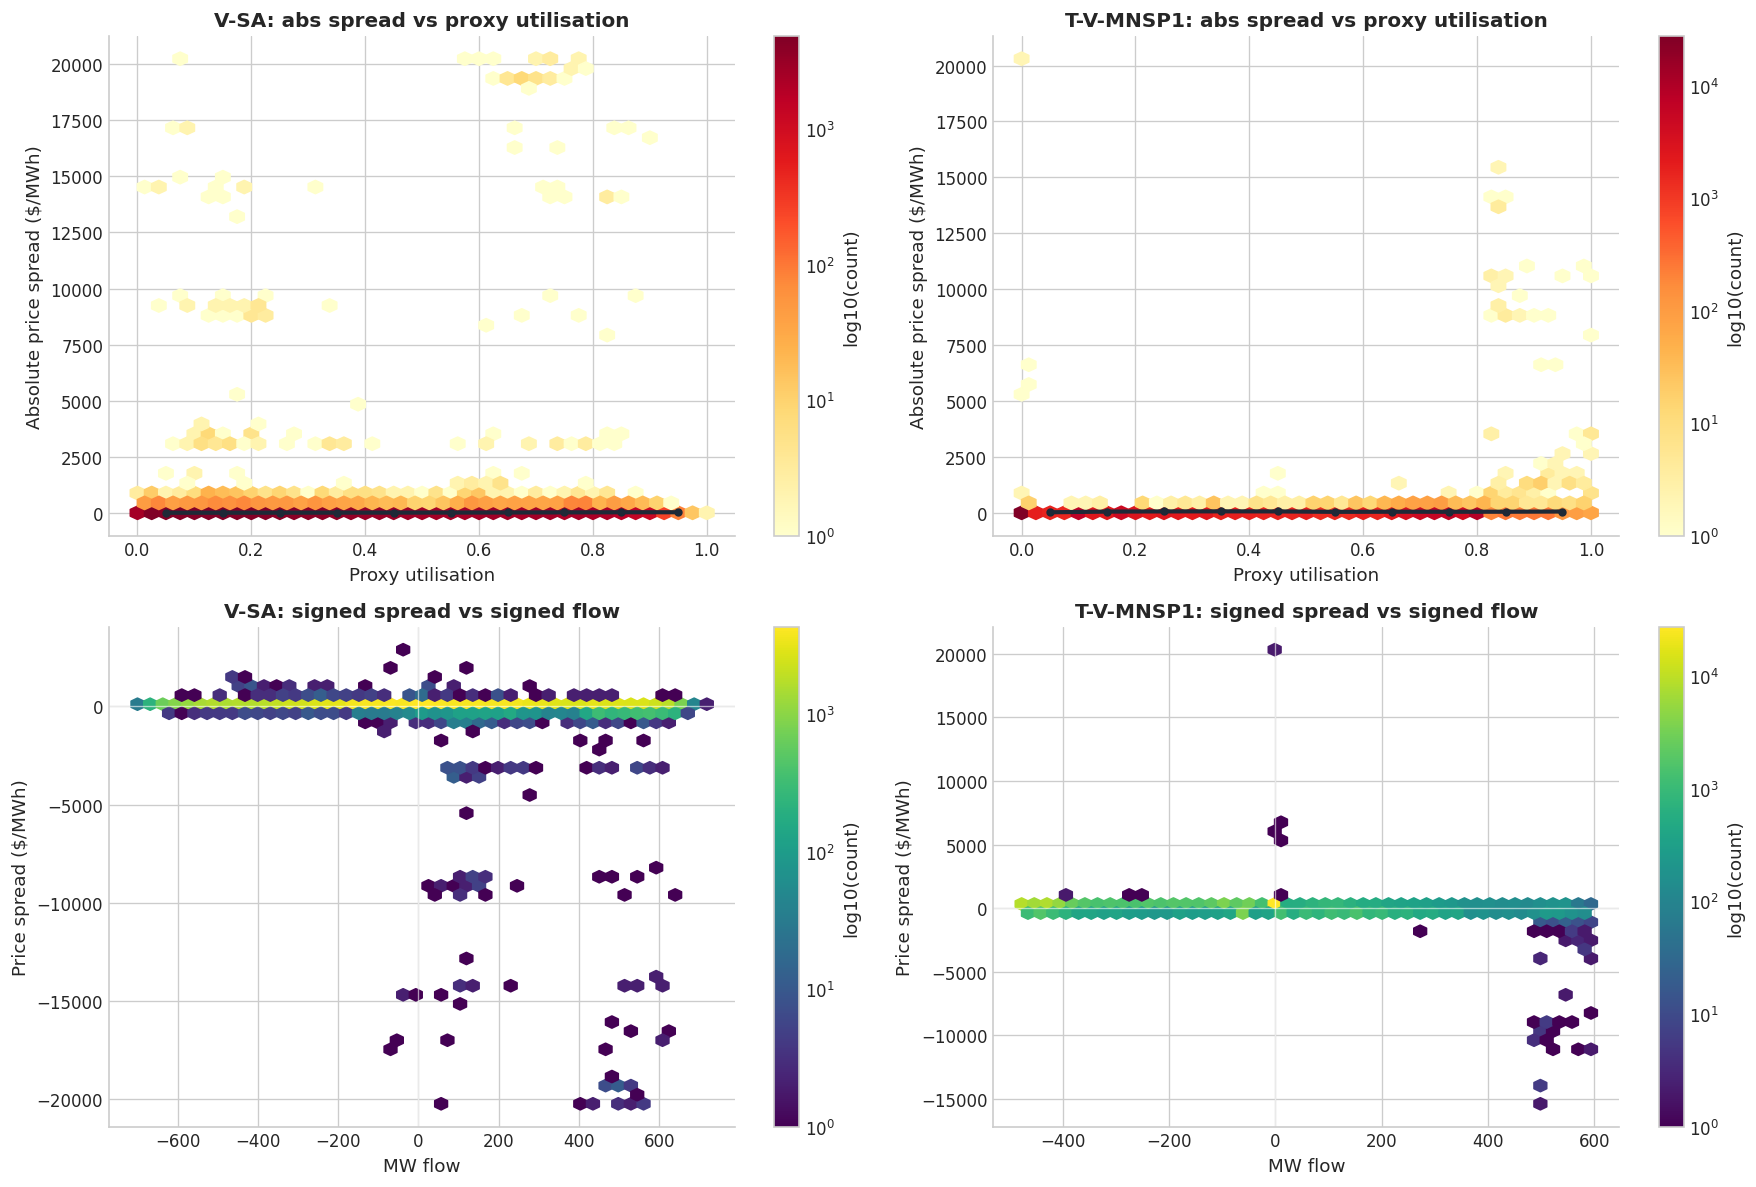

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
util_bins = np.linspace(0, 1, 11)

for col, interconnector_id in enumerate(['V-SA', 'T-V-MNSP1']):
    df = analysis.filter(pl.col('interconnector_id') == interconnector_id).to_pandas()

    ax = axes[0, col]
    hb = ax.hexbin(
        df['utilisation_proxy'],
        df['abs_price_spread'],
        gridsize=40,
        cmap='YlOrRd',
        mincnt=1,
        bins='log',
    )
    add_median_by_bin(ax, df['utilisation_proxy'], df['abs_price_spread'], util_bins, '#1f2937')
    ax.set_title(f'{interconnector_id}: abs spread vs proxy utilisation')
    ax.set_xlabel('Proxy utilisation')
    ax.set_ylabel('Absolute price spread ($/MWh)')
    fig.colorbar(hb, ax=ax, label='log10(count)')

    ax2 = axes[1, col]
    hb2 = ax2.hexbin(
        df['mw_flow'],
        df['price_spread'],
        gridsize=45,
        cmap='viridis',
        mincnt=1,
        bins='log',
    )
    ax2.axhline(0, color='white', linewidth=0.8, alpha=0.6)
    ax2.axvline(0, color='white', linewidth=0.8, alpha=0.6)
    ax2.set_title(f'{interconnector_id}: signed spread vs signed flow')
    ax2.set_xlabel('MW flow')
    ax2.set_ylabel('Price spread ($/MWh)')
    fig.colorbar(hb2, ax=ax2, label='log10(count)')

fig.tight_layout()
plt.show()

## Section 4 — Regional Context Cross-Check

A single interconnector does not equal a region’s whole interchange position, but the time-series below is a useful cross-check: when the interconnector runs hard, the connected regions’ `NETINTERCHANGE` values should tell a consistent import/export story.

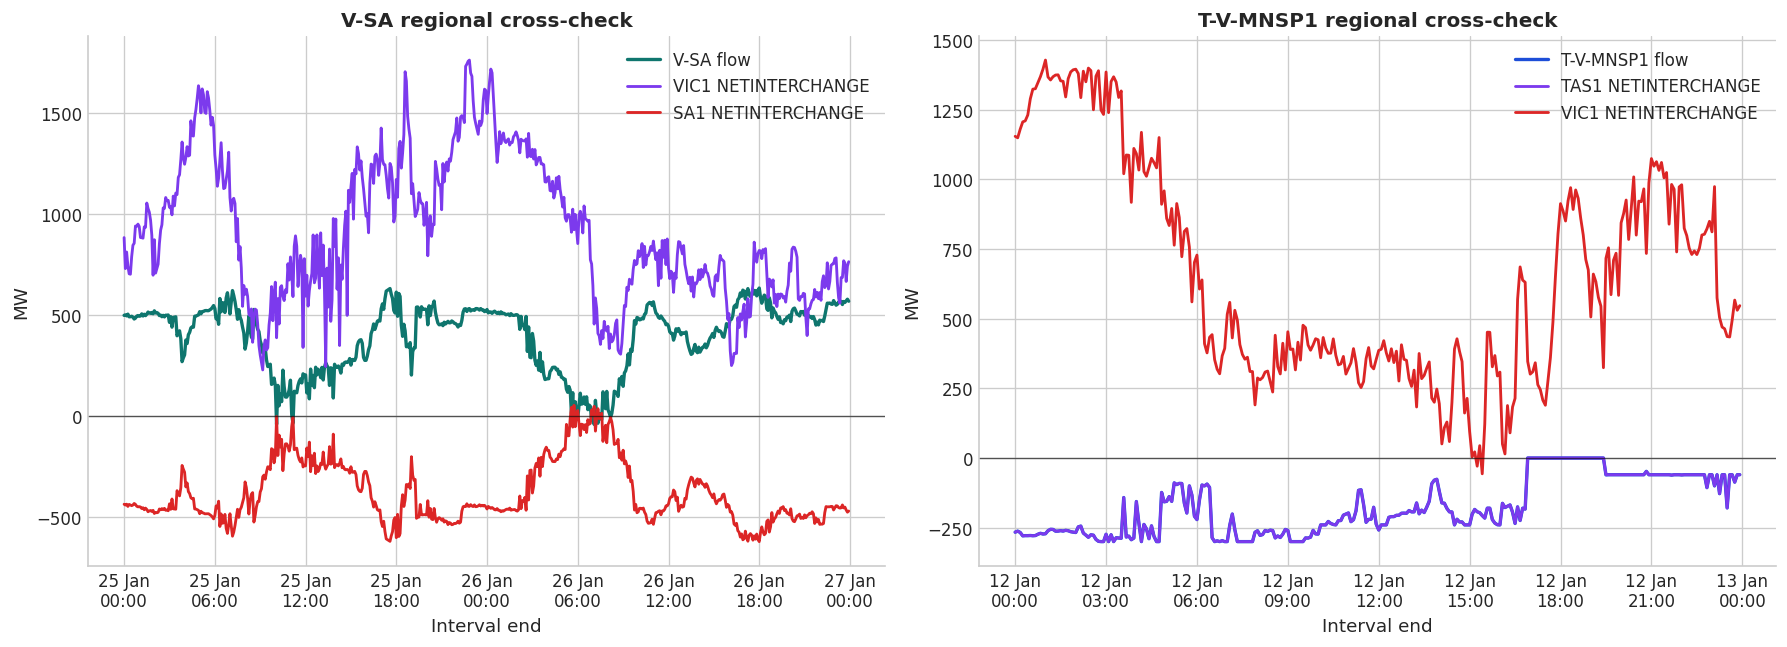

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=False)

for idx, interconnector_id in enumerate(['V-SA', 'T-V-MNSP1']):
    start, end = spotlight_windows[interconnector_id]
    df = (
        analysis.filter(
            (pl.col('interconnector_id') == interconnector_id)
            & pl.col('interval_end').is_between(start, end, closed='left')
        )
        .to_pandas()
        .sort_values('interval_end')
    )

    ax = axes[idx]
    ax.plot(df['interval_end'], df['mw_flow'], color=COLOR_MAP[interconnector_id], linewidth=2, label=f'{interconnector_id} flow')
    ax.plot(df['interval_end'], df['net_interchange_a'], color='#7c3aed', linewidth=1.7, label=f"{df['region_a'].iloc[0]} NETINTERCHANGE")
    ax.plot(df['interval_end'], df['net_interchange_b'], color='#dc2626', linewidth=1.7, label=f"{df['region_b'].iloc[0]} NETINTERCHANGE")
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{interconnector_id} regional cross-check')
    ax.set_ylabel('MW')
    ax.set_xlabel('Interval end')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%H:%M'))
    ax.legend(loc='upper right')

fig.tight_layout()
plt.show()

## Section 5 — Findings

The last cell turns the core statistics into short analyst takeaways. These are intentionally descriptive and stop short of exact binding attribution.

In [16]:
metrics = {}
for interconnector_id in ['V-SA', 'T-V-MNSP1']:
    df = analysis.filter(pl.col('interconnector_id') == interconnector_id)
    util_p90 = df.select(pl.col('utilisation_proxy').quantile(0.9)).item()
    spread_p95 = df.select(pl.col('abs_price_spread').quantile(0.95)).item()
    high_util = df.filter(pl.col('utilisation_proxy') >= util_p90)
    metrics[interconnector_id] = {
        'mean_abs_spread': float(df['abs_price_spread'].mean()),
        'mean_abs_spread_high_util': float(high_util['abs_price_spread'].mean()),
        'mean_util_top_spread': float(df.filter(pl.col('abs_price_spread') >= spread_p95)['utilisation_proxy'].mean()),
        'mean_util_all': float(df['utilisation_proxy'].mean()),
    }

summary_pd = summary.to_pandas().set_index('interconnector_id')
findings_md = f"""
### Analyst Takeaways

- **Observed envelope, not hard limit.** Every utilisation statement in this notebook is based on the largest realised absolute flow in the cached sample, because the trimmed local `DISPATCHINTERCONNECTORRES` parquet does not preserve raw transfer-limit columns.
- **`V-SA` is directional but not one-way.** The series ranged from **{summary_pd.loc['V-SA', 'min_flow_mw']:.0f} MW** to **{summary_pd.loc['V-SA', 'max_flow_mw']:.0f} MW**, with reverse flow in **{summary_pd.loc['V-SA', 'share_reverse_flow_pct']:.1f}%** of intervals. That is enough reversal to matter, but the signed duration curve still shows a clear dominant transfer pattern.
- **Basslink-like behaviour is more two-way.** `T-V-MNSP1` reversed in **{summary_pd.loc['T-V-MNSP1', 'share_reverse_flow_pct']:.1f}%** of intervals, more often than `V-SA`, which is visible in both the signed duration curve and the signed spread-vs-flow panel.
- **Tighter observed flow conditions coincide with larger spreads.** On `V-SA`, mean absolute price separation rises from **${metrics['V-SA']['mean_abs_spread']:.1f}/MWh** overall to **${metrics['V-SA']['mean_abs_spread_high_util']:.1f}/MWh** in the top utilisation decile. On `T-V-MNSP1`, it rises from **${metrics['T-V-MNSP1']['mean_abs_spread']:.1f}/MWh** to **${metrics['T-V-MNSP1']['mean_abs_spread_high_util']:.1f}/MWh**.
- **The relationship is real but not mechanical.** The average proxy utilisation during the top 5% of spread intervals is **{metrics['V-SA']['mean_util_top_spread']:.3f}** on `V-SA` versus **{metrics['V-SA']['mean_util_all']:.3f}** overall, and **{metrics['T-V-MNSP1']['mean_util_top_spread']:.3f}** on `T-V-MNSP1` versus **{metrics['T-V-MNSP1']['mean_util_all']:.3f}** overall. Tight flows matter, but they are not the whole story.
- **The spotlight windows match the market intuition.** The SA spotlight reuses the 2026-01-25 to 2026-01-27 event window from Notebook 1.3, while the TAS spotlight selects **{TAS_SPOTLIGHT_START.date()}**, the largest absolute TAS-VIC spread day in the sample.
- **Notebook 1.5 is the next layer.** This notebook shows the symptoms of congestion and separation. The exact answer to "which network constraint bound and why" still belongs in the later constraint-attribution notebook.
"""

display(Markdown(findings_md))


### Analyst Takeaways

- **Observed envelope, not hard limit.** Every utilisation statement in this notebook is based on the largest realised absolute flow in the cached sample, because the trimmed local `DISPATCHINTERCONNECTORRES` parquet does not preserve raw transfer-limit columns.
- **`V-SA` is directional but not one-way.** The series ranged from **-700 MW** to **719 MW**, with reverse flow in **41.7%** of intervals. That is enough reversal to matter, but the signed duration curve still shows a clear dominant transfer pattern.
- **Basslink-like behaviour is more two-way.** `T-V-MNSP1` reversed in **60.0%** of intervals, more often than `V-SA`, which is visible in both the signed duration curve and the signed spread-vs-flow panel.
- **Tighter observed flow conditions coincide with larger spreads.** On `V-SA`, mean absolute price separation rises from **$39.0/MWh** overall to **$62.9/MWh** in the top utilisation decile. On `T-V-MNSP1`, it rises from **$54.6/MWh** to **$100.7/MWh**.
- **The relationship is real but not mechanical.** The average proxy utilisation during the top 5% of spread intervals is **0.427** on `V-SA` versus **0.378** overall, and **0.620** on `T-V-MNSP1` versus **0.364** overall. Tight flows matter, but they are not the whole story.
- **The spotlight windows match the market intuition.** The SA spotlight reuses the 2026-01-25 to 2026-01-27 event window from Notebook 1.3, while the TAS spotlight selects **2026-01-12**, the largest absolute TAS-VIC spread day in the sample.
- **Notebook 1.5 is the next layer.** This notebook shows the symptoms of congestion and separation. The exact answer to "which network constraint bound and why" still belongs in the later constraint-attribution notebook.
